In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LogisticRegression

sns.set_style()
sns.set_theme()

In [2]:
data = pd.read_csv('data/Experience_vs_Promotion_Data.csv')
data.head(20)

,Years of Experience,Promotion
0,7.490802,1
1,19.014286,1
2,14.639879,1
3,11.973170,1
4,3.120373,0
5,3.119890,0
6,1.161672,0
7,17.323523,1
8,12.022300,1
9,14.161452,1


Text(0.5, 1.0, 'Promotion vs years of experience')

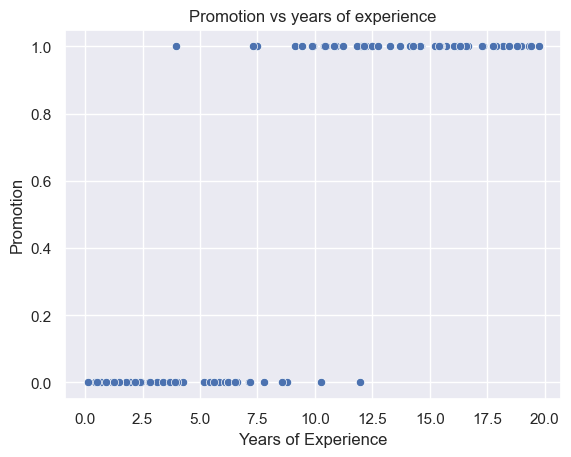

In [3]:
sns.scatterplot(data, x='Years of Experience', y='Promotion')
plt.title('Promotion vs years of experience')

In [4]:
target = data['Promotion']
features = data[['Years of Experience']]

In [5]:
features

,Years of Experience
0,7.490802
1,19.014286
2,14.639879
3,11.973170
4,3.120373
...,...
95,9.875912
96,10.454657
97,8.550820
98,0.508383


In [6]:
# Fit logistic regression model
model = LogisticRegression()
model.fit(features, target)

# Extract learned coefficients
true_coef = model.coef_[0][0]
true_intercept = model.intercept_[0]

In [7]:
true_coef

np.float64(0.7838314770711702)

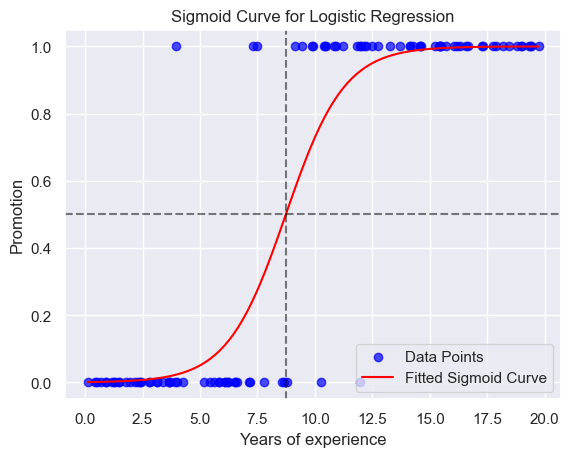

In [8]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-(true_coef * x + true_intercept)))

# Generate x values for a smooth sigmoid curve
x_values = np.linspace(features.min(), features.max(), 100)
sigmoid_curve = sigmoid(x_values)

# Plot actual data points
plt.scatter(features, target, label="Data Points", color="blue", alpha=0.7)

# Plot the sigmoid curve
plt.plot(x_values, sigmoid_curve, label="Fitted Sigmoid Curve", color="red")

# Labels and title
plt.xlabel("Years of experience")  # Replace with actual feature name
plt.ylabel("Promotion")
plt.title("Sigmoid Curve for Logistic Regression")

plt.axhline(y=0.5, color="black", linestyle="dashed", alpha=0.5)  # Horizontal line at 0.5
plt.axvline(x=-true_intercept/true_coef, color="black", linestyle="dashed", alpha=0.5)  # Vertical line at 0

plt.legend()

# Show plot
plt.show()


In [9]:
probas = model.predict_proba(features)
probas

array([[7.26408871e-01, 2.73591129e-01],
       [3.17095312e-04, 9.99682905e-01],
       [9.68741625e-03, 9.90312584e-01],
       [7.33086251e-02, 9.26691375e-01],
       [9.87897400e-01, 1.21026000e-02],
       [9.87901920e-01, 1.20980800e-02],
       [9.97368194e-01, 2.63180601e-03],
       [1.19225292e-03, 9.98807747e-01],
       [7.07350702e-02, 9.29264930e-01],
       [1.40333412e-02, 9.85966659e-01],
       [9.98536280e-01, 1.46371981e-03],
       [2.34712965e-04, 9.99765287e-01],
       [2.02150403e-03, 9.97978496e-01],
       [9.71230371e-01, 2.87696295e-02],
       [9.81971391e-01, 1.80286086e-02],
       [9.81527745e-01, 1.84722549e-02],
       [8.88797052e-01, 1.11202948e-01],
       [2.01264930e-01, 7.98735070e-01],
       [5.19131387e-01, 4.80868613e-01],
       [9.07418433e-01, 9.25815666e-02],
       [6.04385432e-02, 9.39561457e-01],
       [9.90633558e-01, 9.36644204e-03],
       [9.06205641e-01, 9.37943592e-02],
       [7.51137104e-01, 2.48862896e-01],
       [4.251577

In [10]:
pred_class = model.predict(features)
pred_class

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0])

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [12]:
accuracy_score(target, pred_class)

0.94

In [17]:
precision_score(target, pred_class)

0.9423076923076923

In [18]:
recall_score(target, pred_class)

0.9423076923076923

In [15]:
f1_score(target, pred_class)

0.9423076923076923

In [19]:
confusion_matrix(target, pred_class)

array([[45,  3],
       [ 3, 49]])

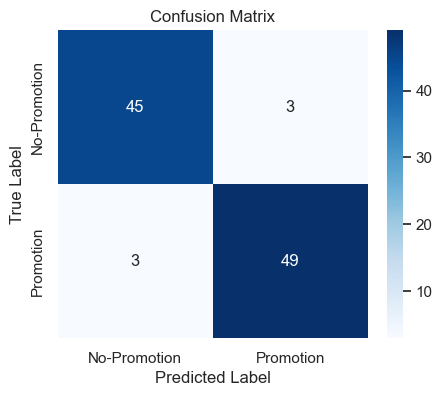

In [20]:
conf_mtx = confusion_matrix(target, pred_class)

class_names = ["No-Promotion", "Promotion"]

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(conf_mtx, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()